In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import scipy.sparse as sp
import pandas as pd
import pygenstability as pgs

from collections import defaultdict

from pygenstability.contrib.sankey import plot_sankey

In [2]:
from src.ms_topic import ms_topic_representation

In [3]:
# We set a global configuration for matplotlib to obtain well-readable plots
SMALL_SIZE = 12
MEDIUM_SIZE = 16
BIGGER_SIZE = 20

plt.rc("font", size=SMALL_SIZE)  # controls default text sizes
plt.rc("axes", titlesize=BIGGER_SIZE)  # fontsize of the axes title
plt.rc("axes", labelsize=MEDIUM_SIZE)  # fontsize of the x and y labels
plt.rc("xtick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("ytick", labelsize=SMALL_SIZE)  # fontsize of the tick labels
plt.rc("legend", fontsize=SMALL_SIZE)  # legend fontsize
plt.rc("figure", titlesize=BIGGER_SIZE)  # fontsize of the figure title

# 1 Load data

Our dataset consists of conspiracy-related news articles from the US. In this study we focus on far-right hyperpartisan media (also called alternative media in this notebook) and legacy media outlets.

First, run the `1_nlp_pipeline.py` script for preprocessing of the documents and computation of document embeddings.

In [4]:
# load preprocessed documents
df = pd.read_csv("data/processed/alt_leg_data_v1_spacy_prep_ent.csv")


In [5]:
# load embeddings
embeddings = np.load("results/embeddings/alt_leg_data_v1_all-mpnet-base-v2_mean.npy")

# normalize embeddings
embeddings = (embeddings.T / np.linalg.norm(embeddings, axis=1)).T

In [6]:
# create column that record whether article is either gr or nwo
df["v2_gr_nwo_bin"] = df["v2_gr_bin"] + df["v2_nwo_bin"]

# create month and year columns
df["date"] = pd.to_datetime(df["date"])
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()
df["year"] = df["date"].dt.year

In [7]:
# exclude left media
considered_docs = np.array(~df["subplatform"].isin(["tpm", "occupyDems"]))
# exclude empty doc with nan embedding, no text in row 921
embed_nan_ind = np.unique(np.argwhere(np.isnan(embeddings))[:, 0])
considered_docs[embed_nan_ind] = False
# restrict embeddings
embeddings = embeddings[considered_docs]

In [8]:
# restrict documents
df = df[considered_docs]
documents = list(df["preprocessed_text"])

In [9]:
# rename column
df.rename(columns={"Unnamed: 0": "id"}, inplace=True)

# reset index for data frame
df.reset_index(inplace=True, drop=True)

# 2 Descriptive Statistics

We report descriptive statistics of our corpus and visualise the number of articles over time. 

For our analysis, we will compare time frames T1 and T2 before and after the launch of Trump's first presidential campaign, respectively.

In [10]:
# launch date of Trump's first presidential campaign
trump_date = pd.to_datetime("16/06/2015", dayfirst=True)
trump_date_year = 2015 + trump_date.day_of_year / 365

# define time periods before and after Trump's campaign launch
T1 = 2011 + (trump_date_year - 2011) / 2
T2 = trump_date_year + (2021 - trump_date_year) / 2

In [11]:
# introduce dummy column for counting
df["count"] = 1

In [12]:
# count documents per platform
df.groupby(by="platform")["count"].sum()

platform
alt_news       19245
legacy_news     3289
Name: count, dtype: int64

In [13]:
# count documents per platform and subplatform
df.groupby(by=["platform", "subplatform"])["count"].sum()

platform     subplatform  
alt_news     blaze             673
             breitbart        5412
             dailycaller      2722
             gatewaypundit    3836
             infowars         6602
legacy_news  NYT              1283
             USAtoday          225
             WP               1310
             WSJ               471
Name: count, dtype: int64

In [14]:
subplatforms_names = {
    "NYT": "NY Times",
    "USAtoday": "USA Today",
    "WP": "Washington Post",
    "WSJ": "Wall Street Journal",
    "blaze": "Blaze",
    "breitbart": "Breitbart",
    "dailycaller": "Daily Caller",
    "gatewaypundit": "Gateway Pundit",
    "infowars": "InfoWars",
}

subplatform_ls = {
    "NYT": "-",
    "USAtoday": "-",
    "WP": "-",
    "WSJ": "-",
    "blaze": "--",
    "breitbart": "--",
    "dailycaller": "--",
    "gatewaypundit": "--",
    "infowars": "--",
}

subplatforms_colors = {
    "NYT": "C0",
    "USAtoday": "C1",
    "WP": "C2",
    "WSJ": "C9",
    "blaze": "C4",
    "breitbart": "C5",
    "dailycaller": "C6",
    "gatewaypundit": "C7",
    "infowars": "C8",
}

In [15]:
years = np.unique(df["year"])
platforms = np.unique(df["platform"])
subplatforms = np.unique(df["subplatform"])

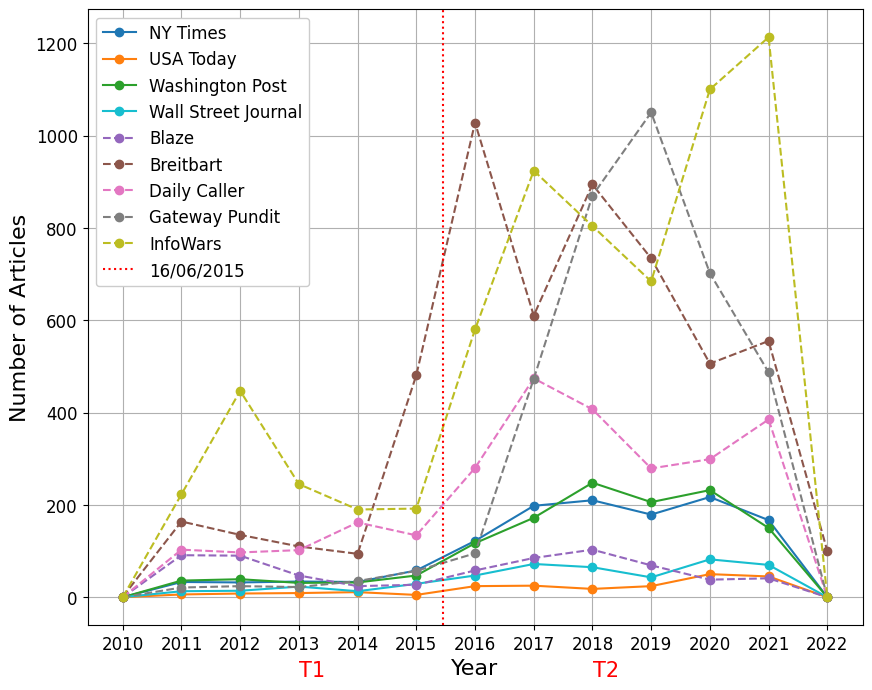

In [16]:
# Plot number of articles over time per subplatform
fig, ax = plt.subplots(1, figsize=(10, 8))

for subplatform in subplatforms:
    counts = [
        defaultdict(
            int,
            df.groupby(by=["subplatform", "year"])["count"]
            .sum()[subplatform]
            .to_dict(),
        )[year]
        for year in years
    ]
    ax.plot(
        years,
        counts,
        ls=subplatform_ls[subplatform],
        label=subplatforms_names[subplatform],
        marker="o",
        color=subplatforms_colors[subplatform],
    )
ax.axvline(x=trump_date_year, color="red", ls=":", label="16/06/2015")
ax.grid()
ax.legend(framealpha=1)
ax.set(xlabel="Year", ylabel="Number of Articles", xticks=years)

# Add annotations T1 and T2
ax.annotate(
    "T1",
    xy=(T1, ax.get_ylim()[0]),  # Position above 2013
    xytext=(T1, ax.get_ylim()[0] - 110),  # Offset above the top of the plot
    ha="center",
    fontsize=15,
    color="red",
)
ax.annotate(
    "T2",
    xy=(T2, ax.get_ylim()[0]),  # Position above 2019
    xytext=(T2, ax.get_ylim()[0] - 110),  # Offset above the top of the plot
    ha="center",
    color="red",
    fontsize=15,
)

plt.savefig(f"figures/medcon_articles_over_time.svg", dpi=fig.dpi, bbox_inches="tight")

We observe that the prevalence of conspiracy-related reporting increases in time period T2.

# 3 Multiscale Topic Modelling - Computations

Next we analyse the topics in our corpus using a graph-based multiscale topic modelling pipeline that follows three steps: (i) computing document embeddings (already done above); (ii) constructing a semantic graph that captures semantic similarities between documents; and (iii) applying multiscale clustering with Markov stability analysis.

Run the `2_ms_pipeline.py` script to apply multiscale topic modelling for different hyperparameters.

In [17]:
# hyperparameters for MS analysis
min_scale = -1
max_scale = 2
n_scale = 300
n_workers = 60
method = "leiden"

# hyperparameters for CkNN graph construction
deltas = [0.5, 0.6, 0.7, 0.9, 1, 1.1, 1.2]
ks = np.arange(7, 16)

### 3.1 Determine optimal hyperparameters

We determine the optimal hyperparameters for our graph construction by evaluating the pointwise mutual information (PMI) of downstream topic models across resolutions.

In [18]:
# initialize lists to store results
ms_results_all = []
n_topics = []
stability_scores = []

# extract results for all combinations of hyperparameters
for delta in deltas:
    ms_results_delta = []
    n_topics_delta = []
    stability_scores_delta = []
    for k in ks:
        ms_result_delta_k = pgs.load_results(
            f"results/ms/alt_leg_data_v1_all-mpnet-base-v2_mean_cknn-k{k}-delta{delta}-mst_ms{min_scale}min{max_scale}max{n_scale}n-{method}_topics_top10.pkl"
        )
        ms_results_delta.append(ms_result_delta_k)
        n_topics_delta.append(ms_result_delta_k["number_of_communities"])
        stability_scores_delta.append(ms_result_delta_k["stability"])
    ms_results_all.append(ms_results_delta)
    n_topics.append(n_topics_delta)
    stability_scores.append(stability_scores_delta)

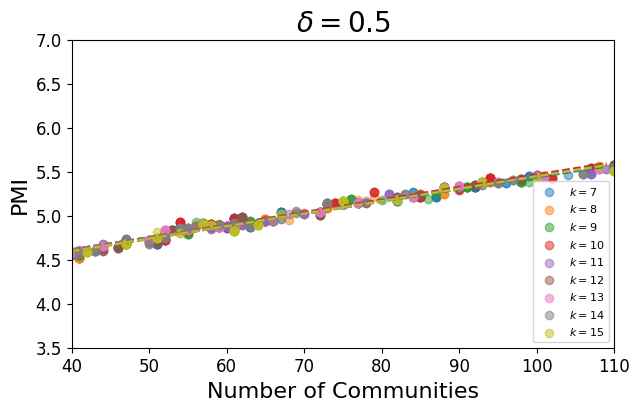

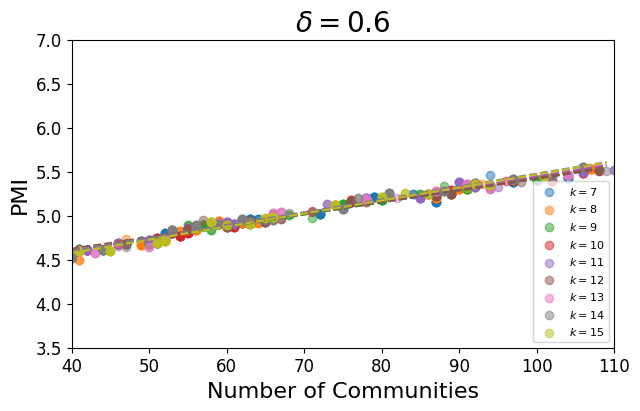

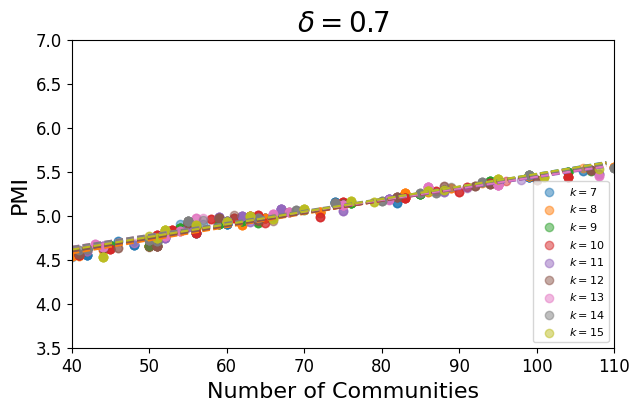

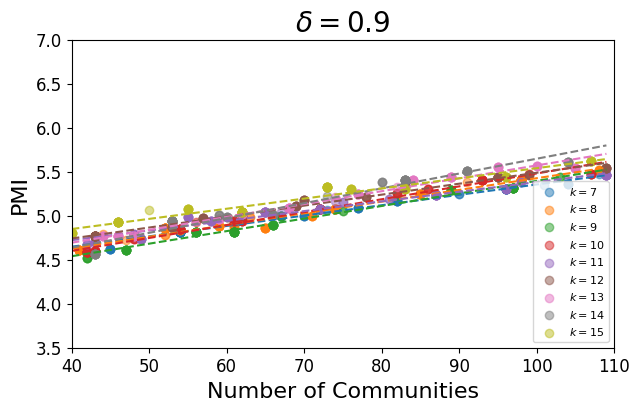

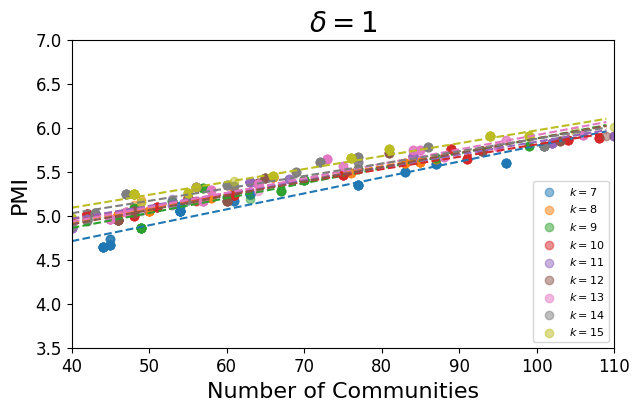

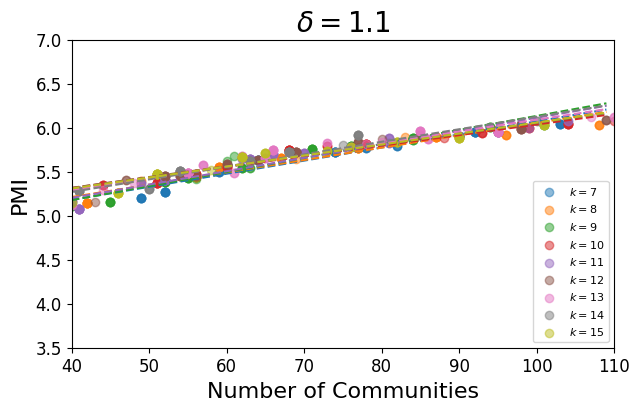

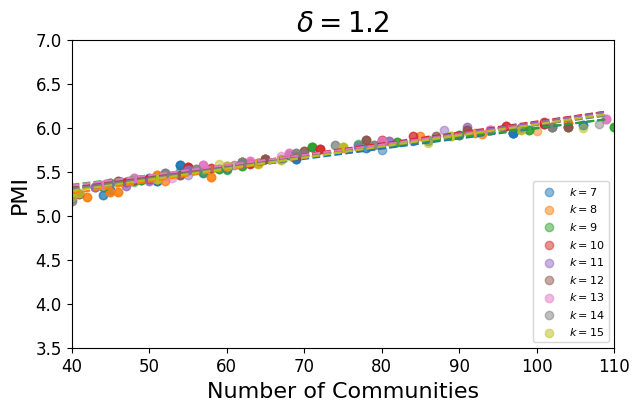

In [19]:
from sklearn.linear_model import LinearRegression
import numpy as np

coefficients = np.zeros((len(deltas), len(ks)))
intercepts = np.zeros((len(deltas), len(ks)))
average_pmis_lr = np.zeros((len(deltas), len(ks)))

n_min = 40
n_max = 110

# plot PMI over number of communities for each combination of hyperparameters and apply LR to capture overall trend of PMI across scales
for i, delta in enumerate(deltas):

    f, ax = plt.subplots(figsize=(7, 4))
    ax.set(
        xlim=(n_min, n_max),
        ylim=(3.5, 7),
        xlabel="Number of Communities",
        ylabel="PMI",
        title=f"$\delta={delta}$",
    )

    for j, k in enumerate(ks):
        ms_result_delta_k = ms_results_all[i][j]
        x = np.array(ms_result_delta_k["number_of_communities"])
        y = np.array(ms_result_delta_k["pmi"])

        # Restrict to the range of x
        mask = (x >= n_min) & (x <= n_max)
        x_restricted = x[mask].reshape(-1, 1)
        y_restricted = y[mask]

        # Apply linear regression
        model = LinearRegression()
        model.fit(x_restricted, y_restricted)
        coefficients[i, j] = model.coef_[0]
        intercepts[i, j] = model.intercept_

        average_pmis_lr[i, j] = model.predict(
            np.array([n_min, n_max]).reshape(-1, 1)
        ).mean()

        # Plot scatter and regression line
        ax.scatter(x_restricted, y_restricted, label=f"$k={k}$", alpha=0.5)
        ax.plot(
            np.arange(n_min, n_max),
            model.predict(np.arange(n_min, n_max).reshape(-1, 1)),
            linestyle="--",
        )

    plt.legend(loc="lower right", fontsize=8)
    plt.show()

Best k: 14
Best delta: 1.1


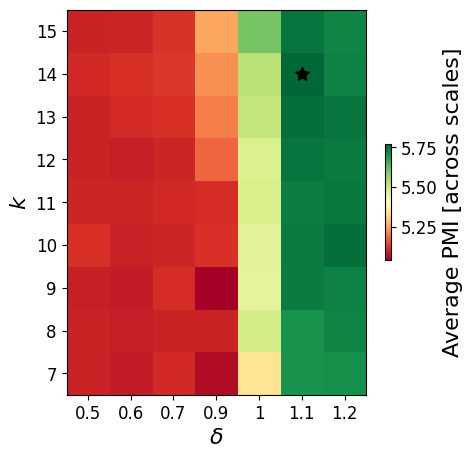

In [20]:
# plot average PMI across scales using linear regression
ind = tuple(np.argwhere(average_pmis_lr == np.nanmax(average_pmis_lr))[0])
optimal_k = ks[ind[1]]
optimal_delta = deltas[ind[0]]
print("Best k:", optimal_k)
print("Best delta:", optimal_delta)
fig, ax = plt.subplots(1, figsize=(5, 5))
im = ax.imshow(average_pmis_lr.T, cmap="RdYlGn", origin="lower")
ax.set(
    xlabel="$\delta$",
    ylabel="$k$",
    xticks=np.arange(len(deltas)),
    yticks=np.arange(len(ks)),
    xticklabels=deltas,
    yticklabels=ks,
)
ax.scatter(ind[0], ind[1], color="black", marker=(5, 1), s=100)
plt.colorbar(im, shrink=0.3, label="Average PMI [across scales]")
plt.show()

After determining the best hyperparameters for CkNN graph, we use the corresponding Markov Stability results.

In [21]:
# load optimal results
ms_results = pgs.load_results(
    f"results/ms/alt_leg_data_v1_all-mpnet-base-v2_mean_cknn-k{optimal_k}-delta{optimal_delta}-mst_ms{min_scale}min{max_scale}max{n_scale}n-{method}_topics_top10.pkl"
)

### 3.2 Scale selection

We apply unsupervised scale selection for Markov Stability to identify the robust topic models at different levels of resolution $k$.

Kernel size: 15, window size: 30, basin radius: 5


[<Axes: xlabel='$log_{10}(t)$', ylabel='$log_{10}(t^\\prime)$'>,
 <Axes: xlabel='$log_{10}(t)$', ylabel='Block NVI'>,
 <Axes: ylabel='Stability'>,
 <Axes: ylabel='# clusters'>,
 <Axes: xlabel='$log_{10}(t)$', ylabel='NVI'>]

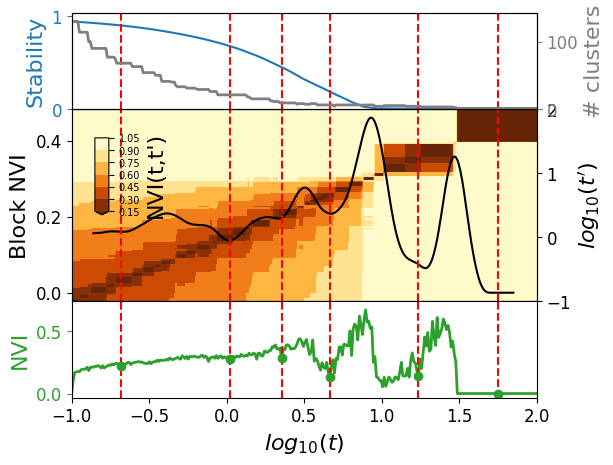

In [22]:
# apply scale selection
kernel_size = int(n_scale / 20)
window_size = int(n_scale / 10)
basin_radius = 5
print(
    f"Kernel size: {kernel_size}, window size: {window_size}, basin radius: {basin_radius}"
)
ms_results = pgs.identify_optimal_scales(
    ms_results,
    kernel_size=kernel_size,
    window_size=window_size,
    basin_radius=basin_radius,
)
pgs.plot_scan(ms_results)

In [23]:
# report optimal number of communities
np.array(ms_results["number_of_communities"])[ms_results["selected_partitions"]]

array([68, 21,  9,  6,  4,  1])

In [24]:
# add topic assignments to data frame for selected partitions
for i in ms_results["selected_partitions"]:
    size = ms_results["number_of_communities"][i]
    if size >= 7:
        df[f"mstopic_{size}"] = ms_results["community_id"][i]

In [25]:
# filter topics from older than 2021 and filter embeddings accordingly
embeddings = embeddings[df["year"] <= 2021]
df = df[df["year"] <= 2021]

# filter topics from previous to 2011 and filter embeddings accordingly
embeddings = embeddings[df["year"] >= 2011]
df = df[df["year"] >= 2011]

In [26]:
# split data into before and after selected data
df_t1 = df[df["date"] < trump_date]
df_t2 = df[df["date"] >= trump_date]

# split data into alternative and legacy media
df_t1_alt = df_t1[df_t1["platform"] == "alt_news"]
df_t1_leg = df_t1[df_t1["platform"] == "legacy_news"]
df_t2_alt = df_t2[df_t2["platform"] == "alt_news"]
df_t2_leg = df_t2[df_t2["platform"] == "legacy_news"]

### 3.3 Topic representation

We compute the most representative words and documents for each topic to facilitate manual coding of the topic labels.

In [27]:
# recompute topic representations with top 15 ngrams
ms_results = ms_topic_representation(
    documents, ms_results, top_n=15, ngram_range=(1, 3)
)

100%|██████████| 300/300 [01:43<00:00,  2.91it/s]


In [28]:
subgroups = [df_t1_alt, df_t1_leg, df_t2_alt, df_t2_leg]
subgroup_names = ["t1_alt", "t1_leg", "t2_alt", "t2_leg"]

In [29]:
for i in [0, 1, 2]:

    n_topics = np.array(ms_results["number_of_communities"])[
        ms_results["selected_partitions"][i]
    ]
    topic_info = ms_results["topic_info"][ms_results["selected_partitions"][i]].copy()

    topic_info["repr_doc_t1_alt"] = None
    topic_info["repr_doc_t1_leg"] = None
    topic_info["repr_doc_t2_alt"] = None
    topic_info["repr_doc_t2_leg"] = None

    # load optimal graph
    A = sp.load_npz(
        f"results/graphs/alt_leg_data_v1_all-mpnet-base-v2_mean_cknn_k{optimal_k}_delta{optimal_delta}_mst.npz"
    )

    for j in range(len(topic_info)):

        # get document ids for topic
        topic_node_id = np.where(np.array(df[f"mstopic_{len(topic_info)}"] == j))[0]

        # split into four different groups
        topic_node_ind_t1_alt = np.isin(topic_node_id, np.array(df_t1_alt.index))
        topic_node_ind_t1_leg = np.isin(topic_node_id, np.array(df_t1_leg.index))
        topic_node_ind_t2_alt = np.isin(topic_node_id, np.array(df_t2_alt.index))
        topic_node_ind_t2_leg = np.isin(topic_node_id, np.array(df_t2_leg.index))

        # create subgraph of documents in topic
        G_topic = nx.from_scipy_sparse_array(A[:, topic_node_id][topic_node_id])

        # compute pagerank
        doc_pagerank = np.asarray(list(nx.pagerank(G_topic).values()))

        # for each group representative document is the one with highest pagerank
        if sum(topic_node_ind_t1_alt) > 0:
            representative_doc_id_t1_alt = topic_node_id[topic_node_ind_t1_alt][
                np.argmax(doc_pagerank[topic_node_ind_t1_alt])
            ]
            representative_doc_t1_alt = df.iloc[representative_doc_id_t1_alt][
                "text_prep"
            ]
        else:
            representative_doc_t1_alt = None
        if sum(topic_node_ind_t1_leg) > 0:
            representative_doc_id_t1_leg = topic_node_id[topic_node_ind_t1_leg][
                np.argmax(doc_pagerank[topic_node_ind_t1_leg])
            ]
            representative_doc_t1_leg = df.iloc[representative_doc_id_t1_leg][
                "text_prep"
            ]
        else:
            representative_doc_t1_leg = None
        if sum(topic_node_ind_t2_alt) > 0:
            representative_doc_id_t2_alt = topic_node_id[topic_node_ind_t2_alt][
                np.argmax(doc_pagerank[topic_node_ind_t2_alt])
            ]
            representative_doc_t2_alt = df.iloc[representative_doc_id_t2_alt][
                "text_prep"
            ]
        else:
            representative_doc_t2_alt = None
        if sum(topic_node_ind_t2_leg) > 0:
            representative_doc_id_t2_leg = topic_node_id[topic_node_ind_t2_leg][
                np.argmax(doc_pagerank[topic_node_ind_t2_leg])
            ]
            representative_doc_t2_leg = df.iloc[representative_doc_id_t2_leg][
                "text_prep"
            ]
        else:
            representative_doc_t2_leg = None

        topic_info.loc[j, "repr_doc_t1_alt"] = representative_doc_t1_alt
        topic_info.loc[j, "repr_doc_t1_leg"] = representative_doc_t1_leg
        topic_info.loc[j, "repr_doc_t2_alt"] = representative_doc_t2_alt
        topic_info.loc[j, "repr_doc_t2_leg"] = representative_doc_t2_leg

    topic_info["Label"] = "?"

    topic_info.to_excel(f"results/topics/mstopic_k{n_topics}_info_coding.xlsx")

# 4 Multiscale Topic Modelling - Results

We continue by analysing the results of our multiscale topic model.

### 4.1 Topic labels

First we load the topic labels provided by the manual coding from co-authors.

In [30]:
# we load the topic labels provided by co-authors
labels_68 = pd.read_excel(
    "results/topics/labels/topics_k68_info_coding_finalised.xlsx"
)["Label Final"]
labels_21 = pd.read_excel(
    "results/topics/labels/topics_k21_info_coding_finalised.xlsx"
)["Label Final"]
labels_9 = pd.read_excel("results/topics/labels/topics_k9_info_coding_finalised.xlsx")[
    "Label Final"
]

labels_68 = labels_68.astype(str).str.replace("Unclassified Topic", "Unclassified")
labels_21 = labels_21.astype(str).str.replace("Uncategorized", "Unclassified")
labels_9 = labels_9.astype(str)

topic_labels = [labels_68, labels_21, labels_9]

In [31]:
level = ["F", "M", "C"]
for n in range(3):
    for i in range(len(topic_labels[n])):
        topic_labels[n][i] = f"{level[n]}{i}: {topic_labels[n][i]}"

In [32]:
df["mstopic_68_label"] = df["mstopic_68"].map(
    lambda x: topic_labels[0][x] if pd.notnull(x) else "No topic assigned"
)
df["mstopic_21_label"] = df["mstopic_21"].map(
    lambda x: topic_labels[1][x] if pd.notnull(x) else "No topic assigned"
)
df["mstopic_9_label"] = df["mstopic_9"].map(
    lambda x: topic_labels[2][x] if pd.notnull(x) else "No topic assigned"
)

In [33]:
df

,id,text_prep,title,language,platform,subplatform,date,v1_bin,v2_gr_bin,v2_nwo_bin,...,v2_gr_nwo_bin,month,year,count,mstopic_68,mstopic_21,mstopic_9,mstopic_68_label,mstopic_21_label,mstopic_9_label
1,1,‘Two-speed’ global recovery likely to continu...,The World Is Poorer Still,eng,alt_news,infowars,2011-01-03,True,False,True,...,True,2011-01-01,2011,1,16,7,1,"F16: Finance, Taxation, and Economic Systems","M7: US Power, Culture Wars & Global Order",C1: US Elections and Trump
2,3,Noted author Paul Kengor has unearthed declass...,The ACLU’s untold Stalinist heritage,eng,alt_news,dailycaller,2011-01-04,True,False,False,...,False,2011-01-01,2011,1,12,7,1,"F12: Syrian Conflict, Islamism, and US Foreign...","M7: US Power, Culture Wars & Global Order",C1: US Elections and Trump
3,4,NEW DELHI - Every time \r\nIndian Environment ...,Environmental protection efforts rile pro-deve...,eng,legacy_news,WP,2011-01-04,True,False,False,...,False,2011-01-01,2011,1,24,12,4,F24: Climate Change and Environmental Policy,M12: Climate Change and Abortion,C4: Covid-19 and Health Conspiracies
4,5,The Drug War is a disgrace. Th...,Jim Wallis’ Drug War Deceit,eng,alt_news,infowars,2011-01-07,True,True,False,...,True,2011-01-01,2011,1,41,1,0,F41: Catholicism and Christian Institutions,M1: Racism and White Supremacy,C0: Soros and Conspiracy Narratives
5,6,To: coldwarcomms[at]yahoogroups.comFrom: Omit...,UK Library: Cryptome Blocked for “Criminal Act...,eng,alt_news,infowars,2011-01-07,True,False,True,...,True,2011-01-01,2011,1,9,9,0,F9: Big Tech and Censorship,"M9: Mainstream, Hyperpartisan & Social Media",C0: Soros and Conspiracy Narratives
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22429,23337,Alex Jones and the crew at Infowars have been ...,The Documents That Lead To A Biowarfare Nightmare,eng,alt_news,infowars,2021-12-31,True,False,True,...,True,2021-12-01,2021,1,1,8,5,F1: Alex Jones and Conspiracies,M8: Alex Jones and NWO Conspiracy Theory,C5: Globalist Conspiracies and Alex Jones
22430,23338,"We no longer look to North Korea, Iran, China...",âGod and Cancel Cultureâ Author Urges Amer...,eng,alt_news,gatewaypundit,2021-12-31,True,True,False,...,True,2021-12-01,2021,1,15,7,1,F15: US Ideological Divide and Global Role,"M7: US Power, Culture Wars & Global Order",C1: US Elections and Trump
22431,23339,We reported Wednesday how Deep State operativ...,PART 5: Deep State Operative Don Berlin Has Hi...,eng,alt_news,gatewaypundit,2021-12-31,True,False,False,...,False,2021-12-01,2021,1,17,0,2,F17: Russia–Ukraine Intelligence and FBI Scandals,"M0: Trump, Deep State & FBI Investigations",C2: Deep State and FBI Investigations
22432,23340,As the world prepares for the departure of an ...,Five Global Elections Set to Rock the World in...,eng,alt_news,breitbart,2021-12-31,True,False,True,...,True,2021-12-01,2021,1,19,3,3,F19: French Politics and Far-Right,M3: EU Politics and Immigration,C3: European Politics and Immigration


### 4.2 Statistical analysis of topic shifts in time

We analyse whether there is a significant shift in the topic prevalences in hyperpartisan vs. legacy media from time period T1 to T2, using Fisher's exact test.


In [34]:
from scipy.stats import fisher_exact

In [35]:
topic_info_full_robust_scales = []
topic_info_robust_scales = []
p_values_all = []

for i in range(3):

    # get topic name
    n_topics = np.array(ms_results["number_of_communities"])[
        ms_results["selected_partitions"][i]
    ]
    topic_info = ms_results["topic_info"][ms_results["selected_partitions"][i]].copy()

    # add topic labels
    topic_info["Name"] = topic_labels[i]

    # compute counts for t1/t2 & alt/leg
    for k, subgroup_df in enumerate(subgroups):
        subgroup_df_topic_count_dict = defaultdict(
            int, subgroup_df[f"mstopic_{n_topics}"].value_counts(sort=False).to_dict()
        )
        subgroup_df_topic_count = np.array(
            [subgroup_df_topic_count_dict[j] for j in range(n_topics)]
        )

        topic_info[f"{subgroup_names[k]}_count"] = subgroup_df_topic_count

    # compute counts for t1
    df_t1_topic_count_dict = defaultdict(
        int, df_t1[f"mstopic_{n_topics}"].value_counts(sort=False).to_dict()
    )
    df_t1_topic_count = np.array([df_t1_topic_count_dict[j] for j in range(n_topics)])

    # compute counts for t2
    df_t2_topic_count_dict = defaultdict(
        int, df_t2[f"mstopic_{n_topics}"].value_counts(sort=False).to_dict()
    )
    df_t2_topic_count = np.array([df_t2_topic_count_dict[j] for j in range(n_topics)])

    # compute ratios normalised over timeframe
    topic_info["t1_alt_ratio"] = np.around(
        100 * topic_info["t1_alt_count"] / df_t1_topic_count, 2
    )
    topic_info["t1_leg_ratio"] = np.around(
        100 * topic_info["t1_leg_count"] / df_t1_topic_count, 2
    )
    topic_info["t2_alt_ratio"] = np.around(
        100 * topic_info["t2_alt_count"] / df_t2_topic_count, 2
    )
    topic_info["t2_leg_ratio"] = np.around(
        100 * topic_info["t2_leg_count"] / df_t2_topic_count, 2
    )

    # compute OR and p-values
    pvalues = []
    oddsratios = []

    for k in range(n_topics):
        # get contingency table [[t1_alt, t2_alt], [t1_leg, t2_leg]]
        table = np.array(
            [
                [topic_info["t1_alt_count"][k], topic_info["t2_alt_count"][k]],
                [topic_info["t1_leg_count"][k], topic_info["t2_leg_count"][k]],
            ]
        )
        # compute Fisher's exact test
        res = fisher_exact(table, alternative="two-sided")
        pvalues.append(res.pvalue)
        oddsratios.append(res.statistic)

    oddsratios = np.array(oddsratios)
    pvalues = np.array(pvalues)

    # store p-values for all topics and scales
    p_values_all.append(pvalues)

    # add pvalues and oddsratios to topic_info
    topic_info["OR"] = np.around(oddsratios, 10)
    topic_info["p-value"] = np.around(pvalues, 10)

    # encode topic significance: 1 = significant shift to alternative, -1 = significant shift to legacy, 0 = no significant shift
    topic_info["significance"] = np.where(
        (topic_info["OR"] < 1) & (topic_info["p-value"] < 0.05),
        1,
        np.where((topic_info["OR"] > 1) & (topic_info["p-value"] < 0.05), -1, 0),
    )

    # rank according to OR
    topic_info["OR_rank"] = topic_info["OR"].rank(method="min") / n_topics

    # store full topic info
    topic_info_full = topic_info.copy()
    # remove OR_rank and significance columns
    topic_info_full = topic_info_full.drop(columns=["OR_rank", "significance"])
    topic_info_full_robust_scales.append(topic_info_full)

    # store topic info for Sankey
    topic_info_reduced = topic_info[
        ["Name", "Count", "significance", "Representation", "OR", "p-value", "OR_rank"]
    ]
    topic_info_robust_scales.append(topic_info_reduced)


#### Correction for multiple hypothesis testing

We apply the Benjamini-Yekutieli method to correct for multiple hypothesis testing.


In [36]:
from scipy.stats import false_discovery_control

# apply correction for multiple hypothesis testing across all tests
p_values_all_concatenated = np.concatenate(p_values_all)
adjusted_p_values = false_discovery_control(p_values_all_concatenated, method="by")

In [37]:
# add adjusted p-values back to topic_info_full_robust_scales
counter = 0
for i in range(3):

    topic_info = topic_info_robust_scales[i]

    n_topics = len(topic_info)
    topic_info["adjusted_p-value"] = adjusted_p_values[counter : counter + n_topics]
    topic_info_full_robust_scales[i]["adjusted_p-value"] = adjusted_p_values[
        counter : counter + n_topics
    ]
    counter += n_topics

    # encode topic significance: 1 = significant shift to alternative, -1 = significant shift to legacy, 0 = no significant shift
    topic_info["adjusted_significance"] = np.where(
        (topic_info["OR"] < 1) & (topic_info["adjusted_p-value"] < 0.05),
        1,
        np.where(
            (topic_info["OR"] > 1) & (topic_info["adjusted_p-value"] < 0.05), -1, 0
        ),
    )

In [38]:
# print topics that are not significant anymore after correction
for i in range(3):
    display(
        topic_info_robust_scales[i]["Name"][
            np.abs(
                topic_info_robust_scales[i]["significance"]
                - topic_info_robust_scales[i]["adjusted_significance"]
            )
            > 0
        ]
    )

8            F8: Demonstrations and Protest Movements
9                        F9: Big Tech and Censorship 
13         F13: George Soros and Open Society Network
18     F18: Media Polarization and News Organizations
19                 F19: French Politics and Far-Right
21     F21: Israel, Antisemitism, and Jewish Identity
28                           F28: US–China Relations 
38              F38: Race and White Supremacy Debates
44    F44: Trump Presidency and Separation of Powers 
56                     F56: QAnon Conspiracy Movement
58            F58: Crime, Policing, and Racialization
Name: Name, dtype: object

Series([], Name: Name, dtype: object)

5    C5: Globalist Conspiracies and Alex Jones
Name: Name, dtype: object

In [39]:
# display topic info for fine scale
topic_info_robust_scales[0].head()

,Name,Count,significance,Representation,OR,p-value,OR_rank,adjusted_p-value,adjusted_significance
0,F0: Covid-19 and Anti-Vaccine Narratives,1158,0,"[vaccine, covid, health, virus, covid 19, 19, ...",0.663701,0.139455,0.279412,1.0,0
1,F1: Alex Jones and Conspiracies,672,0,"[alex, alex jones, jones, globalist, break, in...",NaN,1.000000,NaN,1.0,0
2,F2: Hungary and EU Migration Policy,643,0,"[european, hungary, orban, eu, europe, hungari...",0.626118,0.335040,0.250000,1.0,0
3,"F3: FBI, Comey, and Deep State",640,0,"[fbi, comey, investigation, mccabe, page, strz...",inf,1.000000,0.676471,1.0,0
4,F4: Academic and Public Debates on Racial Inju...,626,0,"[black, white, student, school, race, people, ...",1.023953,1.000000,0.397059,1.0,0


In [40]:
# display topic info for medium scale
topic_info_robust_scales[1].head()

,Name,Count,significance,Representation,OR,p-value,OR_rank,adjusted_p-value,adjusted_significance
0,"M0: Trump, Deep State & FBI Investigations",3250,0,"[trump, fbi, president, deep, deep state, stat...",0.675537,0.312627,0.238095,1.000000,0
1,M1: Racism and White Supremacy,2778,0,"[white, black, say, people, police, group, yea...",1.148057,0.312392,0.476190,1.000000,0
2,M2: US Elections and Trump Campaign Discourse,2543,-1,"[trump, say, president, republican, mr, party,...",2.215320,0.000003,0.523810,0.000243,-1
3,M3: EU Politics and Immigration,2137,1,"[european, eu, party, europe, say, brexit, lon...",0.471064,0.000141,0.142857,0.006499,1
4,M4: George Soros,1545,1,"[soros, group, election, fund, million, george...",0.451683,0.000003,0.095238,0.000243,1


In [41]:
# display topic info for coarse scale
topic_info_robust_scales[2].head()

,Name,Count,significance,Representation,OR,p-value,OR_rank,adjusted_p-value,adjusted_significance
0,C0: Soros and Conspiracy Narratives,6045,0,"[say, group, soros, people, trump, white, medi...",1.171045,0.074152,0.666667,1.000000e+00,0
1,C1: US Elections and Trump,5461,-1,"[trump, say, president, people, american, worl...",2.766516,0.000000,0.777778,3.278396e-22,-1
2,C2: Deep State and FBI Investigations,3519,0,"[trump, fbi, president, state, deep, deep stat...",0.550492,0.084560,0.444444,1.000000e+00,0
3,C3: European Politics and Immigration,2614,1,"[european, say, eu, europe, party, country, pe...",0.472017,0.000003,0.333333,2.432138e-04,1
4,C4: Covid-19 and Health Conspiracies,2472,0,"[vaccine, covid, say, people, health, world, c...",1.041915,0.877161,0.555556,1.000000e+00,0


In [42]:
# save as excel files
with pd.ExcelWriter("results/topics/ms_topics_k68_k21_k9_significance.xlsx") as writer:
    for i in range(3):
        topic_info_full_robust_scales[i].to_excel(
            writer,
            sheet_name=f"mstopic_k{np.array(ms_results['number_of_communities'])[ms_results['selected_partitions'][i]]}_info",
            index=False,
        )

### 4.3 Sankey visualisation

We visualise the multiscale topic model with a Sankey diagram and indicate topic shifts with colours.

In [43]:
import plotly.graph_objects as go

In [44]:
# get partitions for selected scales
partitions = [
    ms_results["community_id"][ms_results["selected_partitions"][i]] for i in range(3)
]

In [45]:
import numpy as np

from sklearn.metrics.cluster import contingency_matrix

FLOW_THRESHOLD = 19

M = len(partitions)

# initialise node, link and level lists for sankey
nodes = []
links = []
levels = {}

# iterate through pairs of consecutive partitions and compute contingency matrix to obtain flow values for sankey
for m in range(M - 1):
    p_m = partitions[m]
    n_m = np.max(p_m) + 1
    p_m_plus_one = partitions[m + 1]
    n_m_plus_one = np.max(p_m_plus_one) + 1
    cm = contingency_matrix(p_m, p_m_plus_one)

    # add node information
    if m == 0:
        for i in range(n_m):
            topic_info_i = topic_info_robust_scales[m].iloc[i]
            nodes.append(
                {
                    "id": f"P{m}_C{i}",
                    "name": topic_info_i["Name"],
                    "size": topic_info_i["Count"],
                    "representation": topic_info_i["Representation"][:10],
                    "significant": topic_info_i["adjusted_significance"],
                    "pvalue": topic_info_i["adjusted_p-value"],
                    "OR": topic_info_i["OR"],
                    "OR_rank": topic_info_i["OR_rank"],
                }
            )
    for j in range(n_m_plus_one):
        topic_info_j = topic_info_robust_scales[m + 1].iloc[j]
        nodes.append(
            {
                "id": f"P{m+1}_C{j}",
                "name": topic_info_j["Name"],
                "size": topic_info_j["Count"],
                "representation": topic_info_j["Representation"][:10],
                "significant": topic_info_j["adjusted_significance"],
                "pvalue": topic_info_j["adjusted_p-value"],
                "OR": topic_info_j["OR"],
                "OR_rank": topic_info_j["OR_rank"],
            }
        )

    # add edges
    for i in range(n_m):
        for j in range(n_m_plus_one):
            cm_ij = cm[i, j]
            if cm_ij > FLOW_THRESHOLD:
                links.append(
                    {
                        "sourceid": f"P{m}_C{i}",
                        "targetid": f"P{m+1}_C{j}",
                        "value": int(cm_ij),
                    }
                )


In [46]:
# compute coordinates for sankey plot based on OR rank and partition number to obtain a more informative layout
x_coordinates = []
y_coordinates = []

for i in range(len(nodes)):
    x_coordinates.append(float(nodes[i]["id"][1]) / 2)
    y_coordinates.append(nodes[i]["OR_rank"])

x_coordinates = [0.001 if v == 0 else 0.999 if v == 1 else v for v in x_coordinates]
y_coordinates = [0.001 if v == 0 else 0.999 if v == 1 else v for v in y_coordinates]

In [47]:
# Prepare node labels, colors, hover text, sizes, OR, and p-value
topic_labels = [node["name"] for node in nodes]
colors = [
    (
        "grey"
        if node["significant"] == 0
        else "orange" if node["significant"] == 1 else "purple"
    )
    for node in nodes
]

# Use RGBA color for transparency
colors = [
    (
        "rgba(255, 165, 0, 1)"
        if node["OR"] <= 1 and node["pvalue"] < 0.05
        else (
            "rgba(255, 165, 0, 0.3)"
            if node["OR"] <= 1 and node["pvalue"] >= 0.05
            else (
                "rgba(140, 0, 244, 1)"
                if node["OR"] > 1 and node["pvalue"] < 0.05
                else "rgba(140, 0, 244, 0.3)"
            )
        )
    )  # if node['OR'] <1 and node['pvalue'] >= 0.05
    for node in nodes
]

hover_text = [node["representation"] for node in nodes]
sizes = [node["size"] for node in nodes]
OR_values = [node["OR"] for node in nodes]
pvalues = [node["pvalue"] for node in nodes]

# Prepare source, target, and value lists for the links
source = [
    next(i for i, node in enumerate(nodes) if node["id"] == link["sourceid"])
    for link in links
]
target = [
    next(i for i, node in enumerate(nodes) if node["id"] == link["targetid"])
    for link in links
]
value = [link["value"] for link in links]

# Create the Sankey diagram
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=400,
                thickness=20,
                line=dict(color="black", width=0.5),
                label=topic_labels,
                color=colors,
                hoverinfo="all",
                hovertemplate="<b>Name:</b> %{label}<br><b>Size:</b> %{customdata[1]}<br><b>Representation:</b> %{customdata[0]}<br><b>OR:</b> %{customdata[2]}<br><b>p-value:</b> %{customdata[3]}<extra></extra>",
                customdata=list(zip(hover_text, sizes, OR_values, pvalues)),
            ),
            link=dict(source=source, target=target, value=value, color="lightgrey"),
        )
    ]
)


# Add a legend for node colors
legend_labels = [
    "Shift to Legacy Media (p < 0.05)",
    "Shift to Legacy Media (ns)",
    "Shift to Hyperpartisan Media (p < 0.05)",
    "Shift to Hyperpartisan Media (ns)",
]
legend_colors = [
    "rgba(140, 0, 244, 1)",
    "rgba(140, 0, 244, 0.3)",
    "rgba(255, 165, 0, 1)",
    "rgba(255, 165, 0, 0.3)",
]

# Add scatter traces for the legend
for label, color in zip(legend_labels, legend_colors):
    fig.add_trace(
        go.Scatter(
            x=[None],
            y=[None],
            mode="markers",
            marker=dict(color=color, size=20),
            name=label,
            showlegend=True,
        )
    )

width = 1700
height = 1500

# Update layout to remove grid and axis labels, and set background color
fig.update_layout(
    #    title_text='Multiscale topic modelling of alternative and legacy news media',
    font_size=13.5,
    showlegend=True,
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    hovermode="closest",
    plot_bgcolor="white",  # Set plot background color to white
    paper_bgcolor="white",
    width=width,  # Set the width of the figure
    height=height,  # Set paper background color to white
)

# Save the figure as an HTML file
fig.write_image("figures/multiscale_topics_sankey.svg", width=width, height=height)

# Show the figure
fig.show()

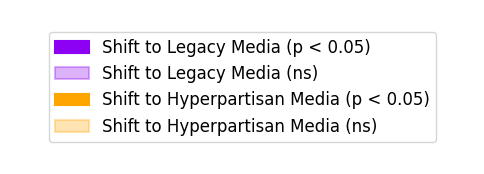

In [48]:
# Create custom legend patches with black edge color

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Define legend labels and colors
legend_labels = [
    "Shift to Legacy Media (p < 0.05)",
    "Shift to Legacy Media (ns)",
    "Shift to Hyperpartisan Media (p < 0.05)",
    "Shift to Hyperpartisan Media (ns)",
]
legend_colors = [
    (140 / 255, 0 / 255, 244 / 255, 1),  # RGBA tuple for purple
    (140 / 255, 0 / 255, 244 / 255, 0.3),  # RGBA tuple for transparent purple
    (255 / 255, 165 / 255, 0 / 255, 1),  # RGBA tuple for orange
    (255 / 255, 165 / 255, 0 / 255, 0.3),  # RGBA tuple for transparent orange
]

# Create a figure for the legend
fig, ax = plt.subplots(figsize=(6, 2))
ax.axis("off")  # Turn off the axis

# Create custom legend patches
legend_patches = [
    mpatches.Patch(color=color, label=label, edgecolor="black", linewidth=1.5)
    for color, label in zip(legend_colors, legend_labels)
]
# Add the legend to the figure
ax.legend(handles=legend_patches, loc="center", frameon=True, fontsize=12)

# Save the legend as an SVG file
plt.savefig("figures/multiscale_topics_legend.svg", format="svg", bbox_inches="tight")
# plt.close()

#### Wide figure version

We also provide a wide figure version.

In [49]:
# hide labels of fine scale
nodes_no_label = [
    {**node, "name": "" if node["id"].startswith("P0_") else node["name"]}
    for node in nodes
]

In [50]:
# Prepare node labels, colors, hover text, sizes, OR, and p-value
topic_labels = [node["name"] for node in nodes_no_label]
colors = [
    (
        "grey"
        if node["significant"] == 0
        else "orange" if node["significant"] == 1 else "purple"
    )
    for node in nodes_no_label
]

# Use RGBA color for transparency
colors = [
    (
        "rgba(255, 165, 0, 1)"
        if node["OR"] <= 1 and node["pvalue"] < 0.05
        else (
            "rgba(255, 165, 0, 0.3)"
            if node["OR"] <= 1 and node["pvalue"] >= 0.05
            else (
                "rgba(140, 0, 244, 1)"
                if node["OR"] > 1 and node["pvalue"] < 0.05
                else "rgba(140, 0, 244, 0.3)"
            )
        )
    )  # if node['OR'] <1 and node['pvalue'] >= 0.05
    for node in nodes_no_label
]

hover_text = [node["representation"] for node in nodes_no_label]
sizes = [node["size"] for node in nodes_no_label]
OR_values = [node["OR"] for node in nodes_no_label]
pvalues = [node["pvalue"] for node in nodes_no_label]

# Prepare source, target, and value lists for the links
source = [
    next(i for i, node in enumerate(nodes_no_label) if node["id"] == link["sourceid"])
    for link in links
]
target = [
    next(i for i, node in enumerate(nodes_no_label) if node["id"] == link["targetid"])
    for link in links
]
value = [link["value"] for link in links]

# Create the Sankey diagram
fig = go.Figure(
    data=[
        go.Sankey(
            arrangement="snap",
            node=dict(
                pad=400,
                thickness=20,
                line=dict(color="black", width=0.5),
                label=topic_labels,
                color=colors,
                hoverinfo="all",
                hovertemplate="<b>Name:</b> %{label}<br><b>Size:</b> %{customdata[1]}<br><b>Representation:</b> %{customdata[0]}<br><b>OR:</b> %{customdata[2]}<br><b>p-value:</b> %{customdata[3]}<extra></extra>",
                customdata=list(zip(hover_text, sizes, OR_values, pvalues)),
            ),
            link=dict(source=source, target=target, value=value, color="lightgrey"),
        )
    ]
)


# Add a legend for node colors
legend_labels = [
    "Shift to Legacy Media (p < 0.05)",
    "Shift to Legacy Media (ns)",
    "Shift to Hyperpartisan Media (p < 0.05)",
    "Shift to Hyperpartisan Media (ns)",
]
legend_colors = [
    "rgba(140, 0, 244, 1)",
    "rgba(140, 0, 244, 0.3)",
    "rgba(255, 165, 0, 1)",
    "rgba(255, 165, 0, 0.3)",
]

width = 1700
height = 950

# Update layout to remove grid and axis labels, and set background color
fig.update_layout(
    #    title_text='Multiscale topic modelling of alternative and legacy news media',
    font_size=15,
    showlegend=True,
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
    hovermode="closest",
    plot_bgcolor="white",  # Set plot background color to white
    paper_bgcolor="white",
    width=width,  # Set the width of the figure
    height=height,  # Set paper background color to white
)

# Show the figure
fig.show()

### 4.4 UMAP visualisation

We can also visualise the topics in the document embedding space directly, using UMAP.

In [51]:
import umap

In [52]:
# reduce embeddings to 2 dimensions with UMAP
umap_model_2d = umap.UMAP(
    n_neighbors=15, n_components=2, min_dist=0.0, metric="cosine", random_state=42
)
embeddings_2d = umap_model_2d.fit_transform(embeddings)

In [53]:
# add UMAP coordinates to data frame
df["UMAP1"] = embeddings_2d[:, 0]
df["UMAP2"] = embeddings_2d[:, 1]

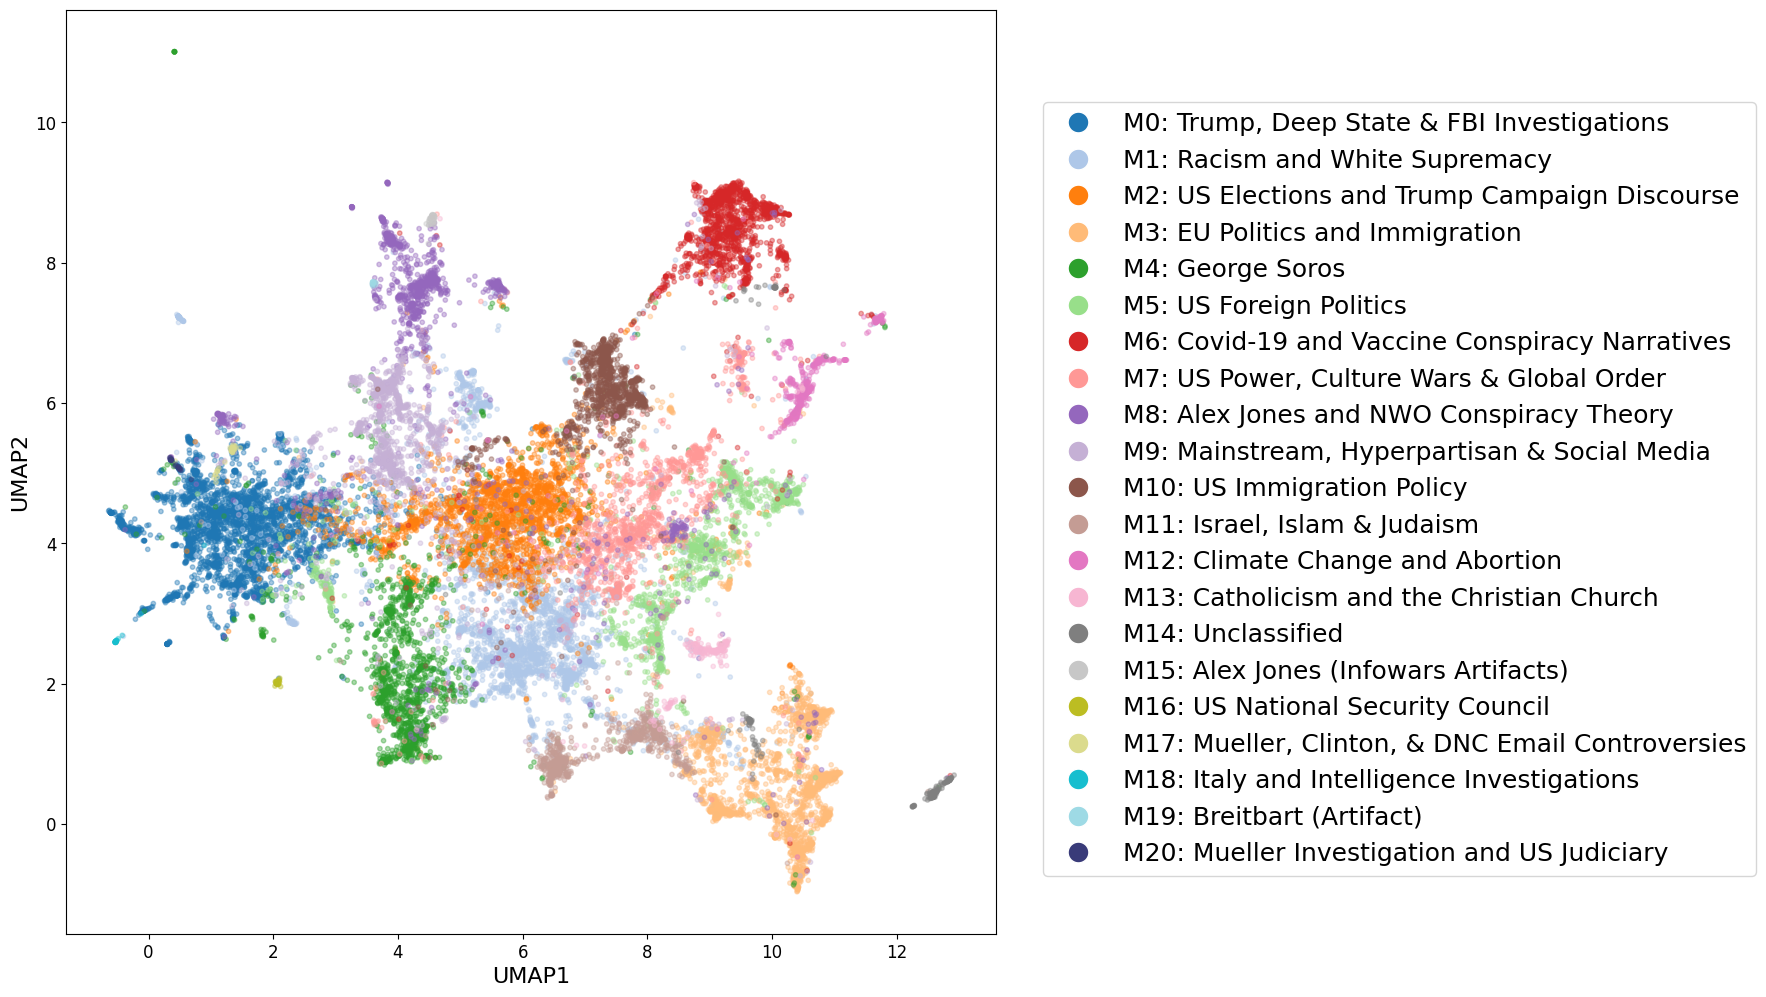

In [54]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# prepare data
df_sorted = df.sort_values(by="mstopic_21")
x = df_sorted["UMAP1"].values
y = df_sorted["UMAP2"].values
labels = df_sorted["mstopic_21_label"].values

# create color map for categories using tab20 (20 colors) + an additional distinct color
unique_labels = list(dict.fromkeys(labels))  # preserve order
n_labels = len(unique_labels)

if n_labels <= 20:
    cmap = plt.get_cmap("tab20")
    colors = {lab: cmap(i) for i, lab in enumerate(unique_labels)}
else:
    # For 21 topics, use tab20 (20 colors) + tab20b for additional distinct colors
    cmap1 = plt.get_cmap("tab20")
    cmap2 = plt.get_cmap("tab20b")
    colors = {}
    for i, lab in enumerate(unique_labels):
        if i < 20:
            colors[lab] = cmap1(i)
        else:
            colors[lab] = cmap2((i - 20) % 20)

point_colors = [colors[l] for l in labels]

# plot
fig, ax = plt.subplots(figsize=(12, 12))
sc = ax.scatter(x, y, c=point_colors, alpha=0.4, s=10)  # s controls point size
ax.set(xlabel="UMAP1", ylabel="UMAP2")

# build legend with larger markers using proxy artists
proxies = [
    Line2D(
        [0],
        [0],
        marker="o",
        color="w",
        markerfacecolor=colors[lab],
        markersize=15,
        linestyle="",
    )
    for lab in unique_labels
]
ax.legend(
    proxies,
    unique_labels,
    fontsize=18,
    bbox_to_anchor=(1.05, 0.90),
    loc="upper left",
    borderaxespad=0,
)

plt.show()

# 5 Named Entities (NEs)

We analyse the NEs mentioned in the articles corresponding to significant topics on the medium level.

In [55]:
# identify significant topics for medium scale
topic_k21_significant_ids = np.where(
    topic_info_robust_scales[1]["adjusted_p-value"] < 0.05
)[0]

### 5.1 Dictionary of persons

We define a dictionary that consists of the top 40 person entities from each of the significant topics.

In [56]:
ent = "person_entities"

entities = []

for id in topic_k21_significant_ids:

    df_topic_id = df[df["mstopic_21"] == id]

    nes_topic = df_topic_id[ent].str.strip("[]").str.split(",").explode().astype(str)
    nes_topic = nes_topic.str.replace("’s", "", regex=False)
    nes_topic = nes_topic.str.replace("s’", "s", regex=False)
    nes_topic = nes_topic.str.replace("'", "", regex=False)
    nes_topic = nes_topic.str.replace('"', "", regex=False)
    nes_topic = nes_topic.str.replace(" -", "", regex=False)
    nes_topic = nes_topic.str.replace("- ", "", regex=False)
    nes_topic = nes_topic.str.replace(r"\bthe\b", "", regex=True)

    # remove certain entities manually
    nes_topic = nes_topic.str.replace("U. S.", "", regex=False)
    nes_topic = nes_topic.str.replace("U. N.", "", regex=False)
    nes_topic = nes_topic.str.replace("Breitbart London", "", regex=False)
    nes_topic = nes_topic.str.replace("Breitbart London Follow", "", regex=False)
    nes_topic = nes_topic.str.replace("Charlie Hebdo", "", regex=False)
    nes_topic = nes_topic.str.replace("Uncle Sam", "", regex=False)
    nes_topic = nes_topic.str.replace("Prison Planet.com", "", regex=False)

    # adapt misspelled entities
    nes_topic = nes_topic.str.replace("Donald Trumps", "Donald Trump", regex=False)
    nes_topic = nes_topic.str.replace(
        "Emmanuel Macrons", "Emmanuel Macron", regex=False
    )
    nes_topic = nes_topic.str.replace("George Soros-", "George Soros", regex=False)
    nes_topic = nes_topic.str.replace("George Soross", "George Soros", regex=False)
    nes_topic = nes_topic.str.replace(
        "Hillary Clintons", "Hillary Clinton", regex=False
    )
    nes_topic = nes_topic.str.replace("Kim Jong-un", "Kim Jong Un", regex=False)
    nes_topic = nes_topic.str.replace("Angela Merkels", "Angela Merkel", regex=False)
    nes_topic = nes_topic.str.replace("Barack Obamas", "Barack Obama", regex=False)

    nes_topic = nes_topic.str.strip()

    # remove certain incomplete entities (Le Pen, Le Pens)
    nes_topic = nes_topic.str.replace("Le Pen", "", regex=False)
    nes_topic = nes_topic.str.replace("Le Pens", "", regex=False)

    nes_topic_all = nes_topic.copy()[nes_topic != ""]
    nes_topic_all = nes_topic_all.value_counts()

    nes_topic_phrases = nes_topic.copy()[nes_topic.str.contains(" ")]
    nes_topic_phrases = nes_topic_phrases[nes_topic_phrases != ""]
    nes_topic_phrases = nes_topic_phrases.value_counts()

    entities += list(nes_topic_phrases[:40].index.values)

In [57]:
# deduplicate entities
entities = list(set(entities))

# sort entities
entities.sort()

In [58]:
# consider alternative spellings
alternative_spellings = {
    "Steve Bannon": "Stephen K. Bannon",
    "Donald Trump": "Donald J. Trump",
    "Viktor Orban": "Viktor Orbán",
}

# resolve alternative spellings
entities_without_alternative_spellings = [
    ent for ent in entities if ent not in alternative_spellings.values()
]

# print number of entities
print("Number of person entities:", len(entities_without_alternative_spellings))

Number of person entities: 140


In [59]:
print(entities_without_alternative_spellings)

['Aaron Klein', 'Abraham Lincoln', 'Alex Jones', 'Alex Marlow', 'Alexander Soros', 'Allum Bokhari', 'Andrew Breitbart', 'Andrew Gillum', 'Angela Merkel', 'Barack Obama', 'Bashar al-Assad', 'Bernie Sanders', 'Bill Clinton', 'Bill Gates', 'Boris Johnson', 'Brett Kavanaugh', 'Brian Stelter', 'Charles Koch', 'Chris Tomlinson', 'Chuck Schumer', 'Dan Lyman', 'David Brock', 'David Cameron', 'David Koch', 'Donald Trump', 'Donald Trump Jr.', 'Donald Tusk', 'Elizabeth Warren', 'Elon Musk', 'Emmanuel Macron', 'Eric Holder', 'Francois Hollande', 'Gary Cohn', 'Geert Wilders', 'George Orwell', 'George Soros', 'George W. Bush', 'George Washington', 'Glenn Beck', 'Guy Verhofstadt', 'Harry Reid', 'Henry Kissinger', 'Hillary Clinton', 'Hosni Mubarak', 'Jack Dorsey', 'Jack Montgomery', 'Jacob Rees-Mogg', 'Jared Kushner', 'Jean-Claude Juncker', 'Jean-Marie ', 'Jeb Bush', 'Jeff Bezos', 'Jeff Flake', 'Jeff Sessions', 'Jeremy Corbyn', 'Jim Hoft', 'Joe Biden', 'John Binder', 'John Bolton', 'John Kerry', 'John

After deduplication, we have a dictionary of 140 persons.

### 5.2 Statistical analysis of person occurrences in significant topics

We want to test whether a person is mentioned significantly more often in far-right hyperpartisan or legacy media and apply a Mann Whitney U test with Benjamini-Yekutieli correction.


In [60]:
from scipy.stats import mannwhitneyu

In [61]:
def pvalue_to_significance(pvalue):
    """
    Converts a p-value to its corresponding significance level string.

    Parameters:
        pvalue (float): The p-value to evaluate.

    Returns:
        str: The significance level as a string ('****', '***', '**', '*', 'ns').
    """
    if pvalue < 0.0001:
        return "****"
    elif pvalue < 0.001:
        return "***"
    elif pvalue < 0.01:
        return "**"
    elif pvalue < 0.05:
        return "*"
    else:
        return "ns"

In [62]:
# save results in different sheets in excel file
with pd.ExcelWriter(
    "results/entities/person_entities_k21_significant_topics.xlsx"
) as writer:

    df_ent_all = []

    for id in topic_k21_significant_ids:

        df_topic_id = df[df["mstopic_21"] == id]
        df_topic_id_alt = df_topic_id[df_topic_id["platform"] == "alt_news"]
        df_topic_id_leg = df_topic_id[df_topic_id["platform"] == "legacy_news"]

        entity_counts_total = []
        entity_counts_alt = []
        entity_counts_alt_median = []
        entity_counts_leg_median = []
        entity_counts_alt_mean = []
        entity_counts_leg_mean = []
        entity_counts_leg = []
        p_values_alt_more = []
        p_values_leg_more = []

        for entity in entities_without_alternative_spellings:

            entity_counts_total.append(df_topic_id["text_prep"].str.count(entity).sum())
            alt_counts = df_topic_id_alt["text_prep"].str.count(entity)
            leg_counts = df_topic_id_leg["text_prep"].str.count(entity)

            # correct counts for alternative spellings
            if entity in alternative_spellings.keys():
                alternative_entity = alternative_spellings[entity]
                entity_counts_total[-1] += (
                    df_topic_id["text_prep"].str.count(alternative_entity).sum()
                )
                alt_counts += df_topic_id_alt["text_prep"].str.count(alternative_entity)
                leg_counts += df_topic_id_leg["text_prep"].str.count(alternative_entity)

            entity_counts_alt.append(alt_counts.sum())
            entity_counts_leg.append(leg_counts.sum())
            entity_counts_alt_median.append(alt_counts.median())
            entity_counts_leg_median.append(leg_counts.median())
            entity_counts_alt_mean.append(round(alt_counts.mean(), 3))
            entity_counts_leg_mean.append(round(leg_counts.mean(), 3))
            # perform Mann-Whitney U test to compare counts in alt vs leg and store p-values for both directions
            p_values_alt_more.append(
                mannwhitneyu(alt_counts, leg_counts, alternative="greater").pvalue
            )
            p_values_leg_more.append(
                mannwhitneyu(alt_counts, leg_counts, alternative="less").pvalue
            )

        # correct for multiple hypothesis testing
        p_values_uncorrected = p_values_alt_more + p_values_leg_more
        p_values_corrected = false_discovery_control(p_values_uncorrected, method="by")
        p_values_alt_more_corrected = p_values_corrected[: len(p_values_alt_more)]
        p_values_leg_more_corrected = p_values_corrected[len(p_values_alt_more) :]

        df_ent = pd.DataFrame(
            {
                "person_entity": entities_without_alternative_spellings,
                "total": entity_counts_total,
                "hyperpartisan": entity_counts_alt,
                "legacy": entity_counts_leg,
                # "hyperpartisan_median" : entity_counts_alt_median,
                # "legacy_median" : entity_counts_leg_median,
                "hyperpartisan_mean": entity_counts_alt_mean,
                "legacy_mean": entity_counts_leg_mean,
                "p_hyperpartisan_is_greater": p_values_alt_more,
                "p_hyperpartisan_is_greater_corrected": p_values_alt_more_corrected,
                "p_legacy_is_greater": p_values_leg_more,
                "p_legacy_is_greater_corrected": p_values_leg_more_corrected,
            }
        )

        df_ent["adjusted_significance_hyperpartisan"] = df_ent[
            "p_hyperpartisan_is_greater_corrected"
        ].apply(pvalue_to_significance)
        df_ent["adjusted_significance_legacy"] = df_ent[
            "p_legacy_is_greater_corrected"
        ].apply(pvalue_to_significance)

        df_ent.sort_values("total", ascending=False, inplace=True)
        df_ent = df_ent.iloc[:15]

        df_ent_all.append(df_ent)

        df_ent.to_excel(writer, sheet_name=f"M{id}", index=False)

# 6 Correction for narration style p-values

Finally we apply Benjamini-Yekutieli correction to p-values from a statistical analysis of narration types performed by a co-author.


In [63]:
from scipy.stats import false_discovery_control

In [64]:
# import p-values for narration style provided by co-author
p_values_narration_a_b = np.array(
    [0.000000000000000000007712893, 0.00000000000006656857, 0.00001673367217298661]
)
p_values_narration_c_d = np.array(
    [0.067858403570000849769350282, 1, 0.4442727, 1, 0.6726638]
)

In [65]:
# correct for multiple hypothesis testing
adjusted_p_values_narration_a_b = false_discovery_control(
    p_values_narration_a_b, method="by"
)
print("Adjusted p-values for panels A and B:", adjusted_p_values_narration_a_b)

# correct for multiple hypothesis testing
adjusted_p_values_narration_c_d = false_discovery_control(
    p_values_narration_c_d, method="by"
)
print("Adjusted p-values for panels C and D:", adjusted_p_values_narration_c_d)

Adjusted p-values for panels A and B: [4.24209115e-20 1.83063568e-13 3.06783990e-05]
Adjusted p-values for panels C and D: [0.77471677 1.         1.         1.         1.        ]
